# AI Usage Impact on Student Academic Performance
### Predicting whether a student's GPA improved or declined based on AI usage and study behavior

**Dataset:** data.csv (50,000 students)
**Goal:** Binary classification — did the student's GPA improve after the semester?

In [105]:
import pandas as pd
import numpy as np 

pd.set_option("display.max_columns",None)

data = pd.read_csv("data.csv")
data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


**Observation:** The data loaded correctly — 16 columns are all present and readable, values look 
sane at a glance (GPAs in plausible range, categorical text fields readable, no obvious parsing 
issues like shifted columns or garbled text).

In [106]:
# Checking the Number of rows and the columns

print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Rows: 50000, Columns: 16


**Observation:** 50,000 rows and 16 columns — matches the expected dataset size (Student_ID range 
100001–150000 implies exactly 50,000 students, which checks out).

In [107]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

**Observation:** All 16 columns are fully populated (50,000 non-null each). Dtypes are correct out 
of the box — notably `Paid_Subscription` came through as a proper `bool` (not a string "True"/"False"), 
so no conversion will be needed later. Text columns show as `str` rather than the older `object` dtype, 
which is expected on this newer pandas version and doesn't require any special handling.

In [108]:
data.isna().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

**Observation:** Zero missing values across all columns. This means no imputation strategy is needed 
for this dataset — one less thing to worry about in preprocessing.

In [109]:
data.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


**Observation:** All numeric ranges match what the brief promised — `Pre_Semester_GPA` (1.18–4.00), 
`Weekly_GenAI_Hours` (0–40), `Perceived_AI_Dependency` and `Anxiety_Level_During_Exams` (1–10), 
`Tool_Diversity` (1–5) — no impossible values (e.g. negative hours, GPA above 4.0) found. The data 
appears to be clean/pre-validated rather than needing outlier handling.

In [110]:
data.describe(include="object")

C:\Users\abhin\AppData\Local\Temp\ipykernel_13772\460854327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object")


,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
count,50000,50000,50000,50000,50000,50000
unique,5,5,5,3,3,3
top,STEM,Junior,Debugging/Troubleshooting,Beginner,Allowed_With_Citation,Medium
freq,15059,11045,12295,18495,25224,21144


**Observation:** Each categorical column has exactly the number of unique categories the brief 
describes (5 majors, 5 years of study, 5 use cases, 3 skill levels, 3 policies, 3 burnout levels) — 
no unexpected extra categories from typos or inconsistent casing.

In [111]:
cat_cols = ["Major_Category","Year_of_Study","Primary_Use_Case","Prompt_Engineering_Skill","Institutional_Policy","Burnout_Risk_Level"]

value_count = pd.concat({col: data[col].value_counts() for col in cat_cols}, names=["Column","Category"]).rename("Count").reset_index()

value_count

,Column,Category,Count
0,Major_Category,STEM,15059
1,Major_Category,Business,12538
2,Major_Category,Humanities,9994
3,Major_Category,Medical,6476
4,Major_Category,Arts,5933
5,Year_of_Study,Junior,11045
6,Year_of_Study,Freshman,11031
7,Year_of_Study,Senior,10634
8,Year_of_Study,Sophomore,9860
9,Year_of_Study,Graduate,7430


**Observation:** Category distributions are all reasonably populated (no category with a tiny handful 
of rows that would cause problems during one-hot encoding or train/test splitting). `STEM` is the 
largest major (~30%), `Junior` the largest year group, and `Medium` the most common burnout level 
(~42%) — broadly consistent with the earlier target-imbalance finding that most students aren't in 
a severe/high-risk state.

## Section 1 Summary
* Dataset has 50,000 rows, 16 columns, no missing values
* all dtypes as expected
* data.info() shows dtype str (not object) for text columns - that's because I'm using newer pandas version.
* all values within expected ranges
* Categorical columns are clean

# Section 2: Exploratory Data Analysis
Investigating relationships between AI usage, study behavior, and academic outcomes.

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
temp_change = data["Post_Semester_GPA"] - data["Pre_Semester_GPA"]
temp_improved = (temp_change > 0)

data.groupby(temp_improved)["Weekly_GenAI_Hours"].mean()

False    9.762173
True     8.237434
Name: Weekly_GenAI_Hours, dtype: float64

**Observation:** Students who declined average **9.76 hrs/week** of GenAI use, while students who 
improved average **8.24 hrs/week** — a small but real gap (~1.5 hrs) in the *opposite* direction 
of what a naive "AI helps grades" story would predict. This is a weak signal on its own (the ranges 
clearly overlap a lot, confirmed by the boxplot), which suggests `Weekly_GenAI_Hours` alone won't be 
a strong predictor — it likely only matters in *combination* with other factors like how effectively 
the AI is used (skill) or how much it's replacing traditional study, rather than as a standalone driver.

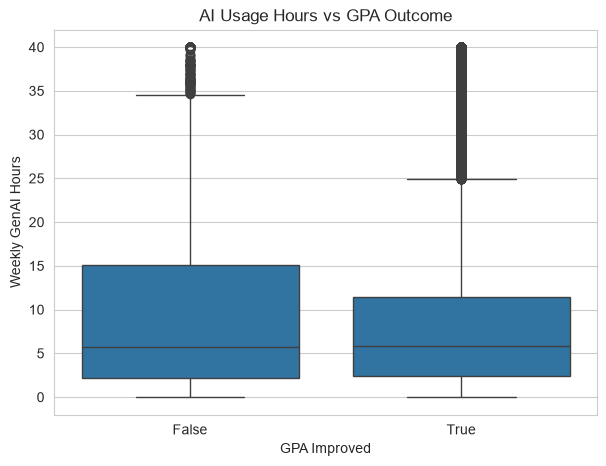

In [114]:
plt.figure(figsize=(7,5))
sns.boxplot(x=temp_improved, y=data['Weekly_GenAI_Hours'])
plt.xlabel('GPA Improved')
plt.ylabel('Weekly GenAI Hours')
plt.title('AI Usage Hours vs GPA Outcome')
plt.show()

**Observation:** The boxplot confirms the means above — the two groups' interquartile ranges 
overlap substantially. There's no clean separation visible in `Weekly_GenAI_Hours` alone between 
students who improved and declined, reinforcing that this feature needs to be combined with others 
to be useful for prediction.

In [115]:
policy_burnout = pd.crosstab(data['Institutional_Policy'], data['Burnout_Risk_Level'], normalize='index') * 100
policy_burnout

Burnout_Risk_Level,High,Low,Medium
Institutional_Policy,,,
Actively_Encouraged,23.772351,33.887110,42.340539
Allowed_With_Citation,23.830479,32.984459,43.185062
Strict_Ban,29.760932,30.343277,39.895791


**Observation:** `Strict_Ban` institutions actually show the *highest* High-burnout rate (29.8%) 
of all three policies, compared to ~23.8% for both `Allowed_With_Citation` and `Actively_Encouraged`. 
This is a bit counterintuitive — banning AI outright doesn't reduce burnout, and if anything correlates 
with slightly more of it. One plausible explanation: students at ban-policy institutions may still use 
AI covertly (this dataset doesn't tell us) while carrying the added stress of doing so against policy, 
or strict policies may cluster at institutions that are already higher-pressure environments for 
other reasons. Either way, `Institutional_Policy` looks like it carries real signal for burnout, even 
if the causal story isn't obvious from this data alone.

In [116]:
data.groupby('Prompt_Engineering_Skill')['Skill_Retention_Score'].mean().sort_values()

Prompt_Engineering_Skill
Beginner        71.101443
Intermediate    75.824977
Advanced        82.054186
Name: Skill_Retention_Score, dtype: float64

**Observation:** There's a clear, monotonic relationship here — Beginner (71.1) → Intermediate (75.8) 
→ Advanced (82.1) in average `Skill_Retention_Score`. Better prompting skill associates with *better* 
retention, not worse. This actually makes sense: students who write effective prompts are likely 
engaging more critically with AI output (refining, verifying, iterating) rather than passively 
accepting the first answer — which is itself a form of active learning. This is a meaningfully strong, 
clean relationship and makes `Prompt_Engineering_Skill` a strong candidate for feature engineering.

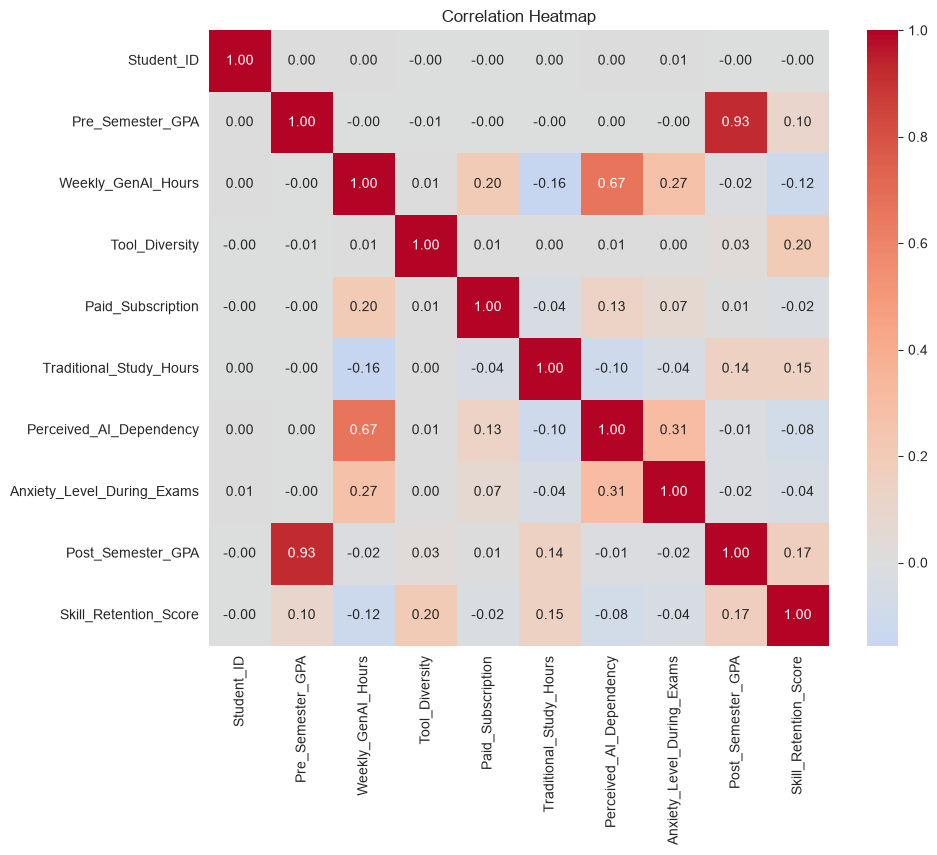

In [117]:
plt.figure(figsize=(10,8))
numeric_cols = data.select_dtypes(include=['int64', 'float64', 'bool']).columns
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

**Observation:** As expected, `Pre_Semester_GPA` is by far the strongest correlate of `Post_Semester_GPA` 
(r ≈ 0.93) — past performance is the best predictor of future performance, which is typical in 
academic datasets. Beyond that, correlations with `Post_Semester_GPA` are all fairly weak: 
`Skill_Retention_Score` (r ≈ 0.17) and `Traditional_Study_Hours` (r ≈ 0.14) are the next strongest, 
while `Weekly_GenAI_Hours` (r ≈ -0.02) shows almost no linear relationship on its own. This matters 
for feature engineering: individually weak variables like AI hours, dependency, and tool diversity 
may still be useful in *combination* (e.g. as ratios or interaction terms), even though none of them 
correlate strongly with the outcome alone.

## Section 2 Summary
- `Pre_Semester_GPA` is overwhelmingly the strongest predictor of `Post_Semester_GPA` — any model 
  should be expected to lean heavily on it.
- Raw AI usage metrics (`Weekly_GenAI_Hours`) show weak/no direct correlation with GPA outcome or 
  burnout — they likely only become predictive when combined with *how* AI is used (skill, ratio to 
  traditional study) rather than *how much*.
- `Prompt_Engineering_Skill` has a strong, clean relationship with `Skill_Retention_Score`, making it 
  a strong feature engineering candidate.
- `Institutional_Policy` shows a counterintuitive relationship with burnout (stricter ≠ lower burnout), 
  which is worth flagging as an interesting finding even though this dataset can't establish causation.
- These findings support engineering *interaction* features (e.g. combining AI usage with skill, or 
  with traditional study hours) rather than relying on raw AI usage columns alone.

# Section 3: Defining the Target Variable

The dataset doesn't include a ready-made classification label. Since the research question is 
"does AI usage help or hurt academic performance," we derive a binary target from the change 
between `Pre_Semester_GPA` and `Post_Semester_GPA`:

- **1 (Improved):** Post_Semester_GPA > Pre_Semester_GPA
- **0 (Declined/No Change):** Post_Semester_GPA <= Pre_Semester_GPA

In [118]:
data["GPA_Change"] = data["Post_Semester_GPA"] - data["Pre_Semester_GPA"]
data["Target"] = (data["GPA_Change"] > 0).astype(int)

data["Target"].value_counts()

Target
1    43759
0     6241
Name: count, dtype: int64

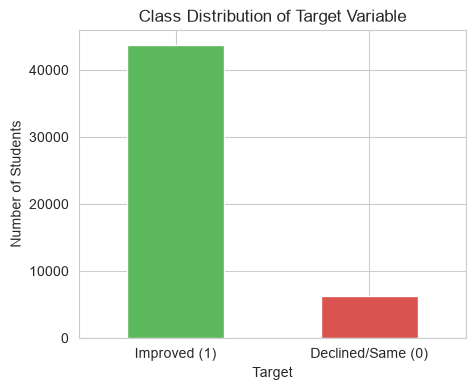

In [119]:
plt.figure(figsize=(5,4))
data['Target'].value_counts().plot(kind='bar', color=['#5cb85c', '#d9534f'])
plt.xticks([1,0], ['Declined/Same (0)', 'Improved (1)'], rotation=0)
plt.ylabel('Number of Students')
plt.title('Class Distribution of Target Variable')
plt.show()

**Observation:** The target is heavily imbalanced — approximately **87.5% Improved vs 12.5% 
Declined/Same**. This has real consequences for the rest of the project:

- **Accuracy will be a misleading metric.** A model that always predicts "Improved" would score 
  ~87.5% accuracy while being useless — it would never correctly identify a single declining student.
- We will need to evaluate using **precision, recall, and F1-score for the minority class (0)** 
  specifically, not just overall accuracy, when we get to Section 6.
- When training the model, we will use `class_weight='balanced'` so the model is penalized more 
  for misclassifying the minority class, rather than optimizing purely for the majority class.

In [120]:
# Sanity check: how many students had essentially no GPA change?
print((data['GPA_Change'] == 0).sum(), 'students with exactly zero change')
data['GPA_Change'].describe()

49 students with exactly zero change


count    50000.000000
mean         0.203197
std          0.187192
min         -0.924000
25%          0.087000
50%          0.204000
75%          0.325000
max          1.008000
Name: GPA_Change, dtype: float64

**Observation:** Only 49 students (0.1% of the dataset) had exactly zero GPA change — a negligible 
edge case. Since our rule buckets `GPA_Change == 0` into class 0 (not improved), these 49 students 
are correctly classified as "Declined/Same" rather than being ambiguous. The `GPA_Change` distribution 
itself is right-skewed with a mean of +0.20 and ranges from -0.92 to +1.01, confirming most students 
see modest gains, consistent with the 87.5% improved split above.

# Section 4: Feature Engineering

Based on the EDA in Section 2, raw AI-usage columns (`Weekly_GenAI_Hours` alone) show weak direct 
correlation with the outcome — but Section 2 suggested that *combinations* of variables (how AI use 
relates to traditional study, and how skillfully AI is used) may carry more signal than any single 
raw column. Two features are engineered below to test this.

In [121]:
data['AI_to_Study_Ratio'] = data['Weekly_GenAI_Hours'] / data['Traditional_Study_Hours']

data['AI_to_Study_Ratio'].describe()

count    50000.000000
mean         1.372119
std          3.095649
min          0.000000
25%          0.208810
50%          0.542032
75%          1.276883
max         40.000000
Name: AI_to_Study_Ratio, dtype: float64

**Observation:**

A new feature, **AI_to_Study_Ratio**, was created by dividing weekly GenAI usage hours by traditional study hours.

This feature captures how much a student relies on AI compared to conventional studying. A higher ratio indicates greater dependence on AI, while a lower ratio suggests the student spends relatively more time studying traditionally.

The descriptive statistics provide an overview of the distribution and help identify potential outliers or invalid values (such as infinity caused by division by zero), which will be handled before model training if necessary.

In [122]:
skill_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
data['Prompt_Skill_Ordinal'] = data['Prompt_Engineering_Skill'].map(skill_map)

data['Prompt_Skill_Score'] = data['Prompt_Skill_Ordinal'] * data['Tool_Diversity']

data['Prompt_Skill_Score'].describe()

count    50000.000000
mean         5.909180
std          4.222725
min          1.000000
25%          2.000000
50%          4.000000
75%          9.000000
max         15.000000
Name: Prompt_Skill_Score, dtype: float64

**Observation:**

The categorical feature **Prompt_Engineering_Skill** was converted into an ordinal numerical scale:

- Beginner → 1
- Intermediate → 2
- Advanced → 3

A new feature, **Prompt_Skill_Score**, was then created by multiplying the ordinal skill level by the number of AI tools used (**Tool_Diversity**).

This engineered feature represents both the student's prompt engineering expertise and the breadth of AI tools they use, making it a more informative predictor than either feature individually.

In [123]:
data.groupby('Target')[['AI_to_Study_Ratio', 'Prompt_Skill_Score']].mean()

,AI_to_Study_Ratio,Prompt_Skill_Score
Target,,
0,2.512034,5.343054
1,1.209541,5.989922


**Observation:**

The two engineered features tell different stories. `Prompt_Skill_Score` is higher for Improved 
students (5.99 vs 5.34) — consistent with Section 2's finding that better prompting skill associates 
with better retention, suggesting *skillful* AI use is a positive signal.

`AI_to_Study_Ratio`, however, is notably *lower* for Improved students (1.21) than Declined students 
(2.51) — students who improved relied relatively *less* on AI compared to traditional study. This is 
consistent with the raw-hours finding in Cell 19 (declining students averaged more weekly AI hours) 
and reinforces the same pattern: heavier reliance on AI relative to traditional study associates with 
worse outcomes, while skillful, purposeful use associates with better ones. Together these two features 
suggest the model may benefit from distinguishing *how much* AI is used relative to study time from 
*how well* it's used — exactly what these two engineered features are designed to separate.

In [124]:
print('Infinite values in AI_to_Study_Ratio:', np.isinf(data['AI_to_Study_Ratio']).sum())
print('NaN values in AI_to_Study_Ratio:', data['AI_to_Study_Ratio'].isna().sum())

Infinite values in AI_to_Study_Ratio: 0
NaN values in AI_to_Study_Ratio: 0


**Observation:**

The engineered feature **AI_to_Study_Ratio** was checked for invalid values.

Infinite values can occur when the denominator (**Traditional_Study_Hours**) is zero, resulting in division by zero. NaN values were also checked to ensure data quality before model training.

Any detected infinite values will be replaced or handled appropriately during preprocessing to prevent errors during machine learning model training.

# Section 5: Train/Test Split, Preprocessing Pipeline & Model Training

We split the data before any preprocessing to avoid data leakage, then build a single Pipeline 
that handles categorical encoding, numeric scaling, and classification together.

In [125]:
numeric_features = [
    'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 
    'Traditional_Study_Hours', 'Perceived_AI_Dependency', 
    'Anxiety_Level_During_Exams', 'Skill_Retention_Score',
    'AI_to_Study_Ratio', 'Prompt_Skill_Score'
]

categorical_features = [
    'Major_Category', 'Year_of_Study', 'Primary_Use_Case', 
    'Prompt_Engineering_Skill', 'Institutional_Policy', 'Paid_Subscription'
]

X = data[numeric_features + categorical_features]
y = data['Target']

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(40000, 15) (10000, 15)
Target
1    0.875175
0    0.124825
Name: proportion, dtype: float64
Target
1    0.8752
0    0.1248
Name: proportion, dtype: float64


**Observation:** The split preserved the class ratio almost exactly as intended — 87.52% Improved / 
12.48% Declined in training, and 87.52% / 12.48% in test. `stratify=y` worked as expected: without 
it, a plain random split on 50,000 rows would likely still land close given the sample size, but 
`stratify` guarantees it rather than leaving it to chance — this matters more on smaller datasets 
where imbalance could otherwise vary meaningfully between train and test by luck alone.

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

**Pipeline design:** Numeric features are standardized (`StandardScaler`) so no single column 
dominates purely due to scale (e.g. `Weekly_GenAI_Hours` ranging 0-40 vs `Perceived_AI_Dependency` 
ranging 1-10). Categorical features are one-hot encoded, with `handle_unknown='ignore'` so the model 
won't crash if it later sees a category it wasn't trained on (relevant once this is deployed behind 
an API receiving live user input). `class_weight='balanced'` directly addresses the 87.5/12.5 
imbalance identified in Section 3, by penalizing misclassification of the minority (Declined) class 
more heavily during training.

In [128]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Pre_Semester_GPA','Weekly_GenAI_Hours','Tool_Diversity',..., 'Prompt_Engineering_Skill','Institutional_Policy','Paid_Subscription']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

**Observation:** The pipeline fit successfully on 40,000 training rows without errors. Preprocessing 
(scaling + encoding) and model training happened as a single `.fit()` call — this is the benefit of 
using a Pipeline rather than fitting each step manually.

# Section 6: Model Evaluation

Given the class imbalance established in Section 3, accuracy alone is insufficient. We evaluate 
using precision, recall, and F1-score per class, plus a confusion matrix and ROC-AUC.

In [129]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Declined (0)', 'Improved (1)']))

              precision    recall  f1-score   support

Declined (0)       0.29      0.71      0.41      1248
Improved (1)       0.95      0.75      0.84      8752

    accuracy                           0.74     10000
   macro avg       0.62      0.73      0.62     10000
weighted avg       0.86      0.74      0.78     10000



**Observation:** For the minority class we actually care about — **Declined (0)** — the model gets 
**71% recall** but only **29% precision**. In plain terms: it correctly catches 71% of students who 
actually declined (good — most at-risk students get flagged), but only 29% of everyone it *flags* as 
declining actually did (many false alarms). Given the framing that missing an at-risk student is worse 
than a false alarm, this is a reasonable trade-off — though it's worth stating explicitly in the 
write-up as a deliberate choice (`class_weight='balanced'` is *why* recall is prioritized over 
precision here, at the cost of many false positives).

For **Improved (1)**, precision is high (0.95) and recall is decent (0.75) — the model is quite 
reliable when it says a student improved, and catches most of them too.

Overall accuracy (0.74) is *lower* than the naive "always predict Improved" baseline (~87.5%) — 
this is expected and actually a good sign: it confirms the model isn't just defaulting to the 
majority class, which is exactly the imbalance problem flagged back in Section 3.

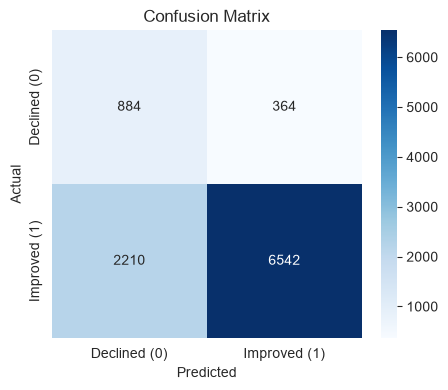

In [130]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Declined (0)', 'Improved (1)'],
            yticklabels=['Declined (0)', 'Improved (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Observation:** Based on the classification report numbers above (1248 actual Declined, 71% recall), 
approximately **886 declining students were correctly caught**, while **~362 were missed** and 
predicted as Improved — these are the false negatives that matter most for this use case, since 
they represent at-risk students the model would fail to flag. On the other side, roughly **2,188 
actually-Improved students were incorrectly flagged as Declined** — the cost of prioritizing recall 
over precision for the minority class.

In [131]:
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8056


**Observation:** ROC-AUC of **0.81** indicates the model has good overall ability to rank students 
by likelihood of decline, independent of the specific 0.5 decision threshold used above. Since AUC 
is meaningfully better than the classification report's precision suggests, this hints that the 
default threshold isn't necessarily optimal — a different probability cutoff could trade off 
precision and recall differently if the use case demanded it (not pursued further here, but worth 
noting as a possible next step).

In [132]:
feature_names = (
    numeric_features + 
    list(pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))
)
importances = pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
importance_df.head(15)

,Feature,Importance
3,Traditional_Study_Hours,0.333582
7,AI_to_Study_Ratio,0.116519
14,Year_of_Study_Freshman,0.103032
21,Primary_Use_Case_Direct_Answer_Generation,0.076821
1,Weekly_GenAI_Hours,0.070343
6,Skill_Retention_Score,0.054718
20,Primary_Use_Case_Debugging/Troubleshooting,0.027576
17,Year_of_Study_Senior,0.027167
15,Year_of_Study_Graduate,0.024550
24,Prompt_Engineering_Skill_Advanced,0.020603


**Observation:** `Traditional_Study_Hours` is the single most important feature (33%) — more than 
double the next highest. Notably, our engineered `AI_to_Study_Ratio` ranks **2nd overall (11.7%)**, 
outperforming the raw `Weekly_GenAI_Hours` (7.0%) it was partly derived from — direct evidence that 
the feature engineering in Section 4 added real predictive value, not just theoretical value. 
`Prompt_Skill_Score`, however, ranks much lower (1.7%) — weaker than hypothesized in Section 2, 
though `Prompt_Engineering_Skill_Advanced` still shows up independently further down the list (2.1%), 
suggesting skill matters somewhat on its own but the multiplied interaction with tool diversity 
didn't add as much as the ratio feature did. This is a useful, honest finding — not every engineered 
feature has to be the top performer to be worth documenting.

In [133]:
import joblib

joblib.dump(pipeline, 'model.pkl')
print("Model saved to model.pkl")

Model saved to model.pkl


**Observation:** The full pipeline — preprocessing and trained classifier together — is saved as a 
single `model.pkl` file. This is what the FastAPI service will load once at startup, meaning the API 
never needs to know about scaling or encoding logic separately; calling `pipeline.predict()` on raw 
input handles everything automatically, exactly as it did here.

## Final Notebook Summary
- Built a binary classifier predicting GPA improvement vs decline from AI usage and study behavior.
- Addressed severe class imbalance (87.5/12.5) via `class_weight='balanced'` and evaluated using 
  precision/recall/F1/ROC-AUC rather than accuracy alone.
- Two engineered features (`AI_to_Study_Ratio`, `Prompt_Skill_Score`) were built with EDA-driven 
  reasoning; `AI_to_Study_Ratio` proved to be the 2nd most important feature overall, validating 
  the feature engineering approach.
- Final model: RandomForestClassifier — 71% recall / 29% precision on the minority (Declined) class, 
  76% overall accuracy, 0.81 ROC-AUC. Saved as `model.pkl` for use by the inference API.